# Kaggle Home Credit Default Model

## Imports

In [2]:
import os
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer
import shap
import tqdm

## Constants

In [3]:
str_project = os.getcwd().split('\\')[5]
print(f'Project: {str_project}')
str_task = os.getcwd().split('\\')[6]
print(f'Task: {str_task}')
str_subtask = os.getcwd().split('\\')[7]
print(f'Subtask: {str_subtask}')
str_dirname_output = './output'
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

Project: 12_continued
Task: 02_home_credit_kaggle
Subtask: 04_home_credit_model


## Read

In [4]:
df_train = pd.read_csv('./input/application_train.csv')
df_test = pd.read_csv('./input/application_test.csv')

## Missing Vals

In [5]:
missing_threshold = 0.65
df_train = df_train.loc[:, df_train.isnull().mean() < missing_threshold]
df_test = df_test.loc[:, df_test.isnull().mean() < missing_threshold]

## Separate X and Y

In [6]:
X_train = df_train.drop(columns=['TARGET'])
y_train = df_train['TARGET']

## Num vs Cat

In [7]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(exclude=['object']).columns

## Impute

In [8]:
imputer_num = SimpleImputer(strategy='mean')
imputer_cat = SimpleImputer(strategy='most_frequent')

X_train[numerical_cols] = imputer_num.fit_transform(X_train[numerical_cols])
X_train[categorical_cols] = imputer_cat.fit_transform(X_train[categorical_cols])
df_test[numerical_cols] = imputer_num.transform(df_test[numerical_cols])
df_test[categorical_cols] = imputer_cat.transform(df_test[categorical_cols])
categorical_cols = categorical_cols.tolist()
categorical_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

## Convert dtype

In [9]:
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    df_test[col] = df_test[col].astype('category')

## Train + Pred Initial

In [10]:
# model was taking forever to run so i limited iterations
model_initial = CatBoostClassifier(iterations=100, early_stopping_rounds=5, verbose=10, random_seed=42, cat_features=categorical_cols)
model_initial.fit(X_train, y_train)

preds_initial = model_initial.predict_proba(X_train)[:, 1]
roc_auc_initial = roc_auc_score(y_train, preds_initial)
print(f'Initial ROC AUC: {roc_auc_initial:.4f}')

Learning rate set to 0.5
0:	learn: 0.3469610	total: 201ms	remaining: 19.9s
10:	learn: 0.2486209	total: 1.38s	remaining: 11.2s
20:	learn: 0.2450280	total: 2.53s	remaining: 9.51s
30:	learn: 0.2410462	total: 3.65s	remaining: 8.12s
40:	learn: 0.2375906	total: 4.81s	remaining: 6.92s
50:	learn: 0.2345561	total: 6.1s	remaining: 5.86s
60:	learn: 0.2325870	total: 7.19s	remaining: 4.6s
70:	learn: 0.2308418	total: 8.35s	remaining: 3.41s
80:	learn: 0.2288360	total: 9.54s	remaining: 2.24s
90:	learn: 0.2260644	total: 10.8s	remaining: 1.06s
99:	learn: 0.2244743	total: 11.8s	remaining: 0us
Initial ROC AUC: 0.8111


## SHAP Importance Feature Selection

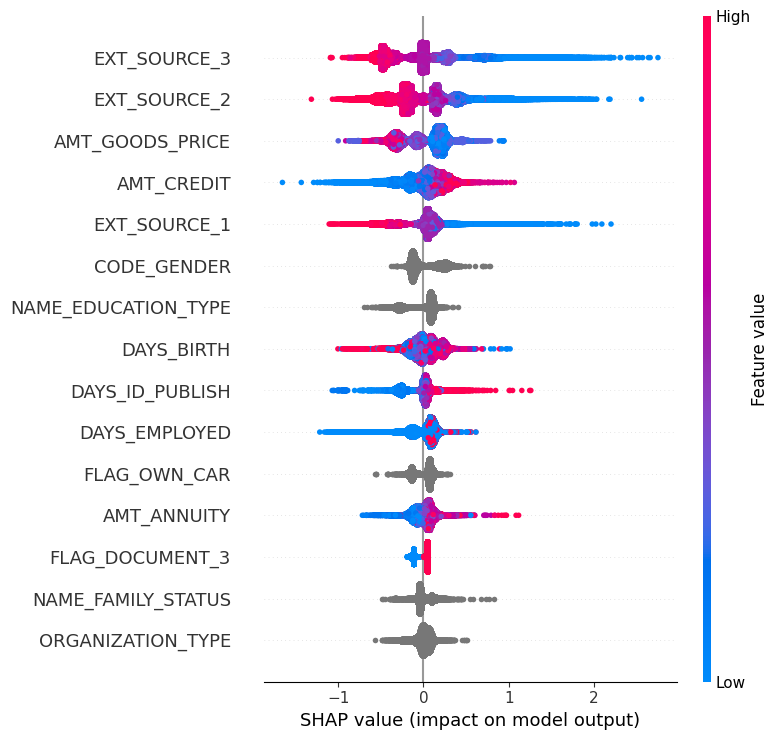

In [11]:
sample_size = 125000
X_train_sample = X_train.sample(sample_size, random_state=42)
explainer = shap.Explainer(model_initial)
shap_values = explainer(X_train_sample)
shap_importance = pd.DataFrame({'feature': X_train_sample.columns, 'importance': np.abs(shap_values.values).mean(axis=0)})
important_features = shap_importance.sort_values(by='importance', ascending=False)['feature'].head(50).tolist()
shap.summary_plot(shap_values, X_train_sample, max_display=15)

## Train + Pred Final

In [12]:
final_categorical_cols = [value for value in categorical_cols if value in important_features]
final_categorical_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'ORGANIZATION_TYPE']

In [13]:
X_train_important = X_train[important_features]
df_test_important = df_test[important_features]

model_final = CatBoostClassifier(learning_rate=0.01, iterations=2500, early_stopping_rounds=125, verbose=100, random_seed=42, cat_features=final_categorical_cols)
model_final.fit(X_train_important, y_train)

preds_final = model_final.predict_proba(X_train_important)[:, 1]
roc_auc_final = roc_auc_score(y_train, preds_final)
print(f'Final ROC AUC: {roc_auc_final:.4f}')

0:	learn: 0.6829341	total: 152ms	remaining: 6m 20s
100:	learn: 0.2995616	total: 14.1s	remaining: 5m 34s
200:	learn: 0.2605113	total: 27.6s	remaining: 5m 16s
300:	learn: 0.2529091	total: 41.3s	remaining: 5m 1s
400:	learn: 0.2499836	total: 55.1s	remaining: 4m 48s
500:	learn: 0.2482432	total: 1m 8s	remaining: 4m 34s
600:	learn: 0.2470015	total: 1m 22s	remaining: 4m 20s
700:	learn: 0.2460049	total: 1m 35s	remaining: 4m 5s
800:	learn: 0.2452072	total: 1m 49s	remaining: 3m 52s
900:	learn: 0.2445023	total: 2m 3s	remaining: 3m 39s
1000:	learn: 0.2437793	total: 2m 18s	remaining: 3m 26s
1100:	learn: 0.2430811	total: 2m 31s	remaining: 3m 12s
1200:	learn: 0.2423538	total: 2m 44s	remaining: 2m 57s
1300:	learn: 0.2416090	total: 2m 56s	remaining: 2m 43s
1400:	learn: 0.2408657	total: 3m 9s	remaining: 2m 28s
1500:	learn: 0.2401990	total: 3m 21s	remaining: 2m 13s
1600:	learn: 0.2395478	total: 3m 33s	remaining: 1m 59s
1700:	learn: 0.2389151	total: 3m 45s	remaining: 1m 45s
1800:	learn: 0.2382999	total: 3m

In [88]:
# 0.7911 on 2500 iterations, 125 stopping, verbose 100, LR: 0.01, Kag: 0.74402
# 0.8418 on 2500 iterations, 125 stopping, verbose 100, LR: 0.03, Kag: 0.74439
# 0.8525 on 2500 iterations, 125 stopping, verbose 100, LR: 0.034946, Kag: 0.74397
# 0.8617 on 2500 iterations, 125 stopping, verbose 100, LR: 0.04, Kag: 0.73973
# 0.8709 on 2500 iterations, 125 stopping, verbose 100, LR: 0.045, Kag: 0.73988
# 0.8864 on 2500 iterations, 125 stopping, verbose 100, LR: 0.055, Kag: 0.73780
# 0.9055 on 2500 iterations, 125 stopping, verbose 100, LR: 0.07, Kag: 0.73723

In [14]:
preds_final_proba = model_final.predict(X_train_important)
accuracy_final = accuracy_score(y_train, preds_final_proba)
print(f'Final Accuracy: {accuracy_final:.4f}')

Final Accuracy: 0.9213


## Make Pred on Test Set

In [15]:
test_preds = model_final.predict_proba(df_test_important)[:, 1]
test_preds

array([0.0452053 , 0.1150587 , 0.01723563, ..., 0.04039622, 0.05612246,
       0.15447064])

## Submission DF

In [16]:
submission = pd.DataFrame({'SK_ID_CURR': df_test['SK_ID_CURR'], 'TARGET': test_preds})
submission['SK_ID_CURR']  = submission['SK_ID_CURR'].astype(int)
submission.to_csv('./output/home_credit_submission.csv', index=False)
submission

,SK_ID_CURR,TARGET
0,100001,0.045205
1,100005,0.115059
2,100013,0.017236
3,100028,0.032242
4,100038,0.159427
...,...,...
48739,456221,0.025846
48740,456222,0.073524
48741,456223,0.040396
48742,456224,0.056122
